# Trabajo Práctico Integrador – Bienestar Digital
## Sexta etapa: Análisis estadístico en Python

**Instituto Politécnico Formosa – Estadística**

**Integrantes:** Ayala, Santiago – Colman, Máximo – Martínez, Javier Nicolás – Pereyra, Ramiro Nicolás – Zigaran, Lucas Natanael

Este programa calcula, analiza y representa gráficamente los conceptos estadísticos
trabajados en las etapas anteriores, utilizando las librerías **Pandas**, **NumPy** y **Matplotlib**.

Variables analizadas:
- Cantidad de horas de redes sociales por día
- Rendimiento académico

In [2]:
# ============================================================
# CARGA DE DATOS Y LIBRERÍAS
# ============================================================
import pandas as pd               # manejo de tablas de datos
import numpy as np                # cálculos numéricos
import matplotlib.pyplot as plt   # gráficos

# Lectura del dataset provisto por la cátedra
datos_estudiantes = pd.read_excel('datos_estudiantes.xlsx')

# Asignamos cada variable a un nombre descriptivo
horas_redes = datos_estudiantes['Horas de consumo de redes sociales por día']
rendimiento_academico = datos_estudiantes['Rendimiento académico']
cantidad_estudiantes = len(datos_estudiantes)   # tamaño de la muestra (n)

print('=' * 60)
print('DATOS CARGADOS CORRECTAMENTE')
print('=' * 60)
print(f'Cantidad de estudiantes encuestados (n): {cantidad_estudiantes}')
datos_estudiantes.head()

DATOS CARGADOS CORRECTAMENTE
Cantidad de estudiantes encuestados (n): 200


,Horas de consumo de redes sociales por día,Rendimiento académico
0,2,9
1,4,8
2,3,8
3,2,8
4,7,7


## 1. Tabla completa de frecuencias
Se construye la tabla de frecuencias de la variable **horas de redes sociales por día**,
con frecuencias absolutas, acumuladas, relativas y porcentuales.

In [8]:
# ============================================================
# 1) TABLA COMPLETA DE FRECUENCIAS
# ============================================================
# Frecuencia absoluta (fi): cuántos estudiantes registran cada valor de horas
tabla_frecuencias = (horas_redes.value_counts()
                                .sort_index()
                                .rename_axis('x (horas)')
                                .reset_index(name='fi'))

# Columnas restantes de la tabla
tabla_frecuencias['Fi']  = tabla_frecuencias['fi'].cumsum()                      # absoluta acumulada
tabla_frecuencias['fri'] = tabla_frecuencias['fi'] / cantidad_estudiantes        # relativa
tabla_frecuencias['Fri'] = tabla_frecuencias['fri'].cumsum()                     # relativa acumulada
tabla_frecuencias['pi%'] = tabla_frecuencias['fri'] * 100                        # porcentual
tabla_frecuencias['Pi%'] = tabla_frecuencias['Fri'] * 100                        # porcentual acumulada

print('TABLA COMPLETA DE FRECUENCIAS')
print(tabla_frecuencias.to_string(index=False))

print('\nINTERPRETACIÓN:')
print('- El valor más frecuente es 4 horas diarias (32 estudiantes, 16% de la muestra).')
print('- El 55,5% de los estudiantes consume hasta 4 horas por día.')
print('- Ningún estudiante registró menos de 1 hora ni más de 8 horas diarias.')

tabla_frecuencias

TABLA COMPLETA DE FRECUENCIAS
 x (horas)  fi  Fi   fri   Fri  pi%   Pi%
         1  24  24 0.120 0.120 12.0  12.0
         2  27  51 0.135 0.255 13.5  25.5
         3  28  79 0.140 0.395 14.0  39.5
         4  32 111 0.160 0.555 16.0  55.5
         5  26 137 0.130 0.685 13.0  68.5
         6  26 163 0.130 0.815 13.0  81.5
         7  24 187 0.120 0.935 12.0  93.5
         8  13 200 0.065 1.000  6.5 100.0

INTERPRETACIÓN:
- El valor más frecuente es 4 horas diarias (32 estudiantes, 16% de la muestra).
- El 55,5% de los estudiantes consume hasta 4 horas por día.
- Ningún estudiante registró menos de 1 hora ni más de 8 horas diarias.


,x (horas),fi,Fi,fri,Fri,pi%,Pi%
0,1,24,24,0.120,0.120,12.0,12.0
1,2,27,51,0.135,0.255,13.5,25.5
2,3,28,79,0.140,0.395,14.0,39.5
3,4,32,111,0.160,0.555,16.0,55.5
4,5,26,137,0.130,0.685,13.0,68.5
5,6,26,163,0.130,0.815,13.0,81.5
6,7,24,187,0.120,0.935,12.0,93.5
7,8,13,200,0.065,1.000,6.5,100.0


## 2. Medidas de tendencia central y de dispersión

In [4]:
# ============================================================
# 2) MEDIDAS DE TENDENCIA CENTRAL Y DE DISPERSIÓN
# ============================================================
# --- Tendencia central ---
media_horas   = horas_redes.mean()          # promedio de horas diarias
mediana_horas = horas_redes.median()        # valor central de la distribución
moda_horas    = horas_redes.mode()[0]       # valor que más se repite

# --- Dispersión (poblacional, ddof=0, como se trabajó en la Etapa 1) ---
varianza_horas = horas_redes.var(ddof=0)                       # varianza
desvio_horas   = horas_redes.std(ddof=0)                       # desvío estándar
coef_variacion = (desvio_horas / media_horas) * 100            # CV en %

# --- Medidas de posición ---
cuartil_1 = horas_redes.quantile(0.25)
cuartil_3 = horas_redes.quantile(0.75)

print('MEDIDAS DE TENDENCIA CENTRAL')
print(f'Media aritmética : {media_horas:.2f} horas')
print(f'Mediana          : {mediana_horas:.2f} horas')
print(f'Moda             : {moda_horas} horas')

print('\nMEDIDAS DE DISPERSIÓN')
print(f'Varianza               : {varianza_horas:.4f}')
print(f'Desvío estándar        : {desvio_horas:.4f} horas')
print(f'Coef. de variación     : {coef_variacion:.2f} %')

print('\nMEDIDAS DE POSICIÓN')
print(f'Cuartil 1 (Q1): {cuartil_1} horas | Cuartil 3 (Q3): {cuartil_3} horas')

print('\nINTERPRETACIÓN:')
print(f'- En promedio los estudiantes usan redes {media_horas:.2f} hs/día, por encima del umbral de 3 hs.')
print('- Media, mediana y moda son muy similares (≈4), la distribución es aproximadamente simétrica.')
print(f'- El CV del {coef_variacion:.1f}% indica una dispersión considerable: los hábitos varían bastante entre estudiantes.')

MEDIDAS DE TENDENCIA CENTRAL
Media aritmética : 4.24 horas
Mediana          : 4.00 horas
Moda             : 4 horas

MEDIDAS DE DISPERSIÓN
Varianza               : 4.4724
Desvío estándar        : 2.1148 horas
Coef. de variación     : 49.88 %

MEDIDAS DE POSICIÓN
Cuartil 1 (Q1): 2.0 horas | Cuartil 3 (Q3): 6.0 horas

INTERPRETACIÓN:
- En promedio los estudiantes usan redes 4.24 hs/día, por encima del umbral de 3 hs.
- Media, mediana y moda son muy similares (≈4), la distribución es aproximadamente simétrica.
- El CV del 49.9% indica una dispersión considerable: los hábitos varían bastante entre estudiantes.


## 3. Gráfico de la distribución de frecuencias

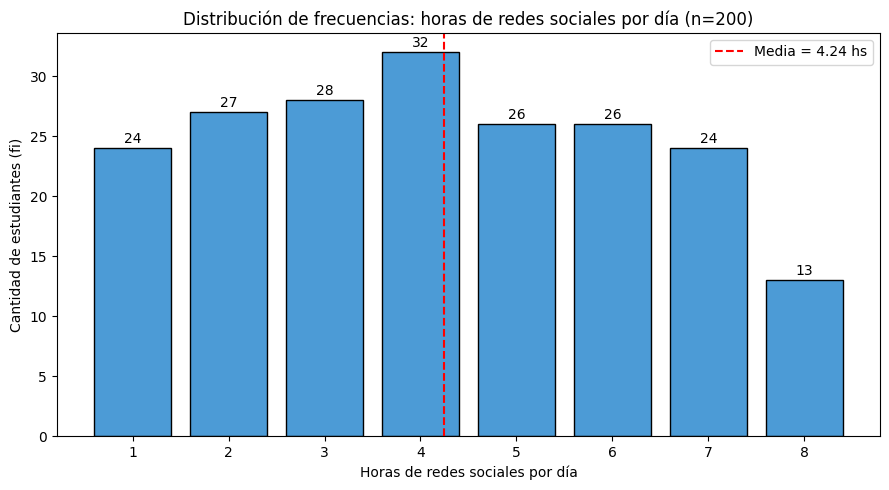

In [5]:
# ============================================================
# 3) GRÁFICO DE BARRAS DE LA DISTRIBUCIÓN DE FRECUENCIAS
# ============================================================
figura_frecuencias, eje_frecuencias = plt.subplots(figsize=(9, 5))

eje_frecuencias.bar(tabla_frecuencias['x (horas)'], tabla_frecuencias['fi'],
                    color='#4C9BD6', edgecolor='black')

eje_frecuencias.set_title('Distribución de frecuencias: horas de redes sociales por día (n=200)')
eje_frecuencias.set_xlabel('Horas de redes sociales por día')
eje_frecuencias.set_ylabel('Cantidad de estudiantes (fi)')

# Etiqueta con el valor de fi sobre cada barra
for posicion_x, frecuencia in zip(tabla_frecuencias['x (horas)'], tabla_frecuencias['fi']):
    eje_frecuencias.text(posicion_x, frecuencia + 0.4, str(frecuencia), ha='center')

# Línea vertical que marca la media
eje_frecuencias.axvline(media_horas, color='red', linestyle='--',
                        label=f'Media = {media_horas:.2f} hs')
eje_frecuencias.legend()
plt.tight_layout()
plt.show()

## 4. Correlación y regresión lineal
Análisis de la relación entre **horas de redes sociales (X)** y **rendimiento académico (Y)**,
replicando en Python lo realizado en Excel en la Etapa 5.

In [6]:
# ============================================================
# 4) CORRELACIÓN Y REGRESIÓN LINEAL
# ============================================================
# Recta de regresión por mínimos cuadrados: y = a + b·x
pendiente_b, ordenada_a = np.polyfit(horas_redes, rendimiento_academico, 1)

# Coeficiente de correlación lineal de Pearson (r)
coef_correlacion_r = np.corrcoef(horas_redes, rendimiento_academico)[0, 1]

# Coeficiente de determinación (r²)
coef_determinacion_r2 = coef_correlacion_r ** 2

print('REGRESIÓN LINEAL Y CORRELACIÓN')
print(f'Pendiente (b)                 : {pendiente_b:.4f}')
print(f'Ordenada al origen (a)        : {ordenada_a:.4f}')
print(f'Recta de regresión            : ŷ = {ordenada_a:.3f} {pendiente_b:+.3f}·x')
print(f'Coef. de correlación (r)      : {coef_correlacion_r:.4f}')
print(f'Coef. de determinación (r²)   : {coef_determinacion_r2:.4f}')

print('\nINTERPRETACIÓN:')
print(f'- Pendiente: por cada hora adicional de redes sociales, el rendimiento')
print(f'  académico disminuye en promedio {abs(pendiente_b):.3f} puntos.')
print(f'- r = {coef_correlacion_r:.3f}: correlación NEGATIVA de intensidad moderada-fuerte.')
print(f'- r² = {coef_determinacion_r2:.3f}: el {coef_determinacion_r2*100:.1f}% de la variabilidad del rendimiento')
print('  se explica por las horas de redes; el resto se debe a otros factores.')

REGRESIÓN LINEAL Y CORRELACIÓN
Pendiente (b)                 : -0.3789
Ordenada al origen (a)        : 9.3965
Recta de regresión            : ŷ = 9.397 -0.379·x
Coef. de correlación (r)      : -0.6856
Coef. de determinación (r²)   : 0.4701

INTERPRETACIÓN:
- Pendiente: por cada hora adicional de redes sociales, el rendimiento
  académico disminuye en promedio 0.379 puntos.
- r = -0.686: correlación NEGATIVA de intensidad moderada-fuerte.
- r² = 0.470: el 47.0% de la variabilidad del rendimiento
  se explica por las horas de redes; el resto se debe a otros factores.


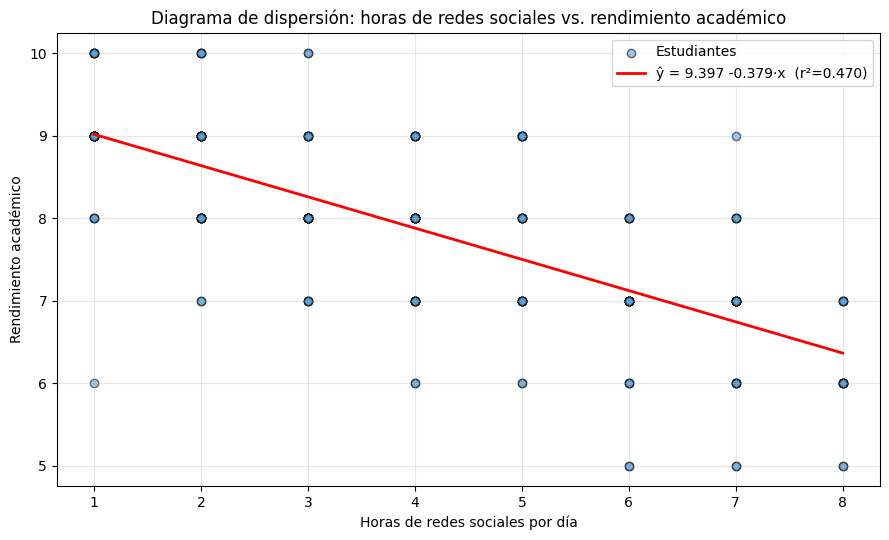

In [7]:
# ============================================================
# 5) DIAGRAMA DE DISPERSIÓN CON RECTA DE REGRESIÓN
# ============================================================
figura_dispersion, eje_dispersion = plt.subplots(figsize=(9, 5.5))

# Nube de puntos (cada punto es un estudiante)
eje_dispersion.scatter(horas_redes, rendimiento_academico,
                       color='#4C9BD6', alpha=0.55, edgecolors='black',
                       label='Estudiantes')

# Recta de regresión evaluada sobre el rango de X
valores_x_recta = np.linspace(horas_redes.min(), horas_redes.max(), 100)
valores_y_recta = ordenada_a + pendiente_b * valores_x_recta
eje_dispersion.plot(valores_x_recta, valores_y_recta, color='red', linewidth=2,
                    label=f'ŷ = {ordenada_a:.3f} {pendiente_b:+.3f}·x  (r²={coef_determinacion_r2:.3f})')

eje_dispersion.set_title('Diagrama de dispersión: horas de redes sociales vs. rendimiento académico')
eje_dispersion.set_xlabel('Horas de redes sociales por día')
eje_dispersion.set_ylabel('Rendimiento académico')
eje_dispersion.legend()
eje_dispersion.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusión del análisis en Python

Los resultados obtenidos con Python coinciden exactamente con los calculados en Excel (Etapa 5)
y con la tabla de frecuencias de la Etapa 4: media = 4,24 hs, recta ŷ = 9,397 − 0,379·x,
r = −0,686 y r² = 0,470. Esto confirma la existencia de una **relación lineal negativa** entre el
tiempo de uso de redes sociales y el rendimiento académico: a mayor consumo diario, menor rendimiento.

La ventaja de Python es que todo el análisis queda **automatizado y reproducible**: si el dataset
cambia, basta con volver a ejecutar el programa para actualizar cálculos e interpretaciones.